In [1]:
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import optuna
import shap
import pickle
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
#プロットの定義
def yyplot(model, Y_test, X_test, Y_train, X_train, title):
    
    m1, s1 = mean_train_y, std_train_y
    m2, s2 = mean_test_y, std_test_y
    
    # 説明変数と目的変数のデータ点の散布図をプロット
    fig = plt.figure(figsize=(5,5))
    fig.suptitle(title, fontsize=15)
    
    s=np.linspace(2.5, 7.5, 50)
    t = s
    plt.plot(s, t, color='k')
    
    #Predict
    train_pred = pd.DataFrame(model.predict(X_train), columns=['pIC50'])
    test_pred = pd.DataFrame(model.predict(X_test), columns=['pIC50'])
    
    #plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='blue', marker='.' , label='training set')
    #plt.scatter(m1 + test_pred*s2, m2 + Y_test*s2, color='red', marker='.' , label='test set')
    plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='none', marker='o' , edgecolor='blue', alpha=0.8, s=80, label='training data')
    plt.scatter(m2 + test_pred*s2, m2 + Y_test*s2, color='red', marker='x' , alpha=0.5, s=120, label='test data')
    
    plt.xlabel('pIC50 Pred')  # x軸のラベル
    plt.ylabel('pIC50 Expt')  # y軸のラベル
    #plt.xlim(2.5, 7.5)
    #plt.ylim(2.5, 7.5)
    plt.legend(loc=2, fontsize=14)
    
    # R2値を表示 
    r2_train = r2_score(Y_train, train_pred).round(4)
    r2_test = r2_score(Y_test, test_pred).round(4)
    
    text1 = f'r2_train={r2_train}'
    text2 = f'r2_test={r2_test}'
    
    plt.text(4.9, 3, text1, fontsize="xx-large", color='blue')
    plt.text(4.9, 2.5, text2, fontsize="xx-large", color='red')

In [3]:
all_data = pd.read_csv('231202_tateishi_a-glucosidase_ECFP4.csv')
seed_list = pd.read_csv("../datasets/split_seed_result.csv")["seed"]
train, test = train_test_split(all_data, test_size=0.2, random_state=seed_list[859])

all_variables =train.columns.values
len(all_variables), len(all_data)

(845, 433)

In [4]:
all_variables

array(['comp_name', 'ChEMBL ID', 'Smiles', 'IC50(nM)', 'IC50(M)', 'pIC50',
       '1', '9', '10', '11', '13', '14', '16', '18', '19', '25', '26',
       '27', '28', '30', '31', '32', '33', '34', '36', '38', '40', '41',
       '43', '45', '47', '51', '53', '54', '56', '57', '58', '60', '62',
       '64', '65', '67', '68', '70', '72', '74', '75', '76', '79', '80',
       '82', '83', '84', '85', '90', '92', '94', '97', '99', '101', '102',
       '103', '104', '105', '107', '109', '110', '114', '115', '116',
       '117', '118', '119', '123', '125', '127', '133', '134', '140',
       '142', '145', '147', '155', '156', '157', '158', '160', '161',
       '162', '164', '165', '167', '170', '172', '174', '178', '182',
       '184', '187', '188', '190', '191', '192', '193', '195', '201',
       '202', '203', '204', '205', '207', '209', '216', '221', '222',
       '227', '230', '231', '233', '235', '237', '239', '240', '241',
       '245', '249', '251', '252', '254', '255', '257', '259', '260',


In [5]:
variables = all_variables[6:]
variables

array(['1', '9', '10', '11', '13', '14', '16', '18', '19', '25', '26',
       '27', '28', '30', '31', '32', '33', '34', '36', '38', '40', '41',
       '43', '45', '47', '51', '53', '54', '56', '57', '58', '60', '62',
       '64', '65', '67', '68', '70', '72', '74', '75', '76', '79', '80',
       '82', '83', '84', '85', '90', '92', '94', '97', '99', '101', '102',
       '103', '104', '105', '107', '109', '110', '114', '115', '116',
       '117', '118', '119', '123', '125', '127', '133', '134', '140',
       '142', '145', '147', '155', '156', '157', '158', '160', '161',
       '162', '164', '165', '167', '170', '172', '174', '178', '182',
       '184', '187', '188', '190', '191', '192', '193', '195', '201',
       '202', '203', '204', '205', '207', '209', '216', '221', '222',
       '227', '230', '231', '233', '235', '237', '239', '240', '241',
       '245', '249', '251', '252', '254', '255', '257', '259', '260',
       '265', '270', '272', '273', '275', '277', '278', '281', '283',
     

In [6]:
#trainig用説明変数
X_train = train[variables]
X_test = test[variables]
X_all = all_data[variables]
x_ori = X_train.columns.values

#test用目的変数
Y_train = train['pIC50']
Y_train=pd.DataFrame(Y_train)
Y_test = test['pIC50']
Y_test=pd.DataFrame(Y_test)
Y_all = all_data['pIC50']
Y_all=pd.DataFrame(Y_all)

#変数の標準化
#ddof=0 標準偏差 ddof=1 不偏標準偏差
ddof = 0

#目的変数についての標準偏差と平均値
mean_train_y =Y_train.mean()
std_train_y = Y_train.std(ddof = ddof)
mean_test_y = Y_test.mean()
std_test_y = Y_test.std(ddof = ddof)
mean_all_y = Y_all.mean()
std_all_y = Y_all.std(ddof = ddof)

#標準化
Y_train_std = (Y_train - mean_train_y) / (std_train_y)
Y_test_std = (Y_test - mean_test_y) / (std_test_y)
Y_all_std = (Y_all - mean_all_y) / (std_all_y)

X_train = X_train
X_test = X_test 
Y_train = Y_train_std
Y_test = Y_test_std
X_all = X_all
Y_all = Y_all_std

#標準化済み確認
len(Y_train_std),len(Y_test_std),len(Y_all_std)

(346, 87, 433)

In [7]:
X_all = all_data[variables]
X_all.shape

(433, 839)

In [39]:
dtrain = xgb.DMatrix(X_train, label=Y_train)
dtest = xgb.DMatrix(X_test, label=Y_test)
dall = xgb.DMatrix(X_all, label=Y_all)

In [40]:
#model.save_model('model.json')

model = xgb.Booster()
model.load_model('best_model/ECFP4_model_859.json')

In [8]:
#プロットの作成
yyplot(model, Y_test, dtest, Y_train, dtrain, "")
#plt.savefig("result_letteryy_plot_T_"+str(i)+".png")
#plt.savefig("result/yy_plot_best_model.png")
#plt.savefig("best_model/論文用_yy_plot_best_model.png")

# SHAP値を計算するためのexplainerを作成
explainer = shap.TreeExplainer(
    model = model,  # 学習済みモデル
    feature_perturbation="interventional"  # 推奨
    )
# SHAP値を計算
shap_values = explainer(X_train, Y_train)

# 棒グラフで重要度を可視化
fig2 = plt.figure(figsize=(5,5))   #新しいウィンドウを描画
fig2.subplots()
shap.plots.bar(shap_values=shap_values, max_display=10, show=False)
#fig2.savefig("result/shap_best_model.png") # 画像を保存

NameError: name 'model' is not defined

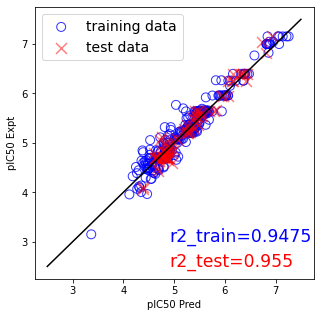

In [9]:
#再学習
model = xgb.Booster()
model.load_model('best_model/ECFP4_model_859.json')

n_estimators = 10000
random_state = 0
max_depth = 5
max_leaves = 5
colsample_bytree = 0.19584222397372023
colsample_bylevel = 0.6752015010221598
colsample_bynode = 0.1507776462876566
subsample = 0.8262822233010625
reg_lambda = 0.00441405009706101
reg_alpha = 0.2483802053169047
leraning_rate = 4.9058033076078384
gamma = 0.34666365628880613

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    "booster":  "gbtree",
    'verbosity' : 0,
    'random_state' : random_state,
    'n_estimators' : 10000,
    'base_score' : float(Y_all.mean().values), 
    'max_depth': max_depth, 
    'max_leaves':max_leaves,
    'colsample_bytree': colsample_bytree,
    'colsample_byrevel': colsample_bylevel,
    'colsample_bynode': colsample_bynode,
    'subsample': subsample,
    "reg_lambda": reg_lambda,
    "reg_alpha": reg_alpha,
    "leraning_rate" : leraning_rate,
    "gamma" : gamma,
}

dtrain = xgb.DMatrix(X_train, label=Y_train)
dtest = xgb.DMatrix(X_test, label=Y_test)
evals = [(dtest, 'eval'), (dtrain, 'train')]

"""#モデルを再学習
model_pro = xgb.train(params=params,
                      xgb_model=model,
                      dtrain=dtest,
                      num_boost_round=10000,
                      early_stopping_rounds=100,
                      evals=evals, 
                      verbose_eval=False,
                         )"""

#モデルを再学習
model_pro = xgb.train(params=params,
                      xgb_model=model,
                      dtrain=dtest,
                      #dtrain=dtrain,
                      num_boost_round=10000,
                      early_stopping_rounds=100,
                      evals=evals, 
                      verbose_eval=False,
                         )

# with構文でファイルパスとバイナリ書き込みモードを設定
with open("best_model/ECFP4_model_pro"+".pickle", mode='wb') as f:
    pickle.dump(model_pro, f)
model_pro.save_model("best_model/ECFP4_model_pro.json")

#プロットの作成
yyplot(model_pro, Y_test, dtest, Y_train, dtrain, "")
#plt.savefig("result/yy_plot_model_pro.png")
plt.savefig("best_model/論文用_yy_plot_model_pro.png")

In [10]:
m3, s3 = mean_all_y, std_all_y
m3, s3

(pIC50    5.277669
 dtype: float64,
 pIC50    0.65642
 dtype: float64)

In [11]:
m2, s2 = mean_test_y, std_test_y
m2, s2

(pIC50    5.271714
 dtype: float64,
 pIC50    0.655029
 dtype: float64)

In [12]:
dall = xgb.DMatrix(X_all, label=Y_all)
all_pred = pd.DataFrame(model_pro.predict(dall), columns=['pIC50'])

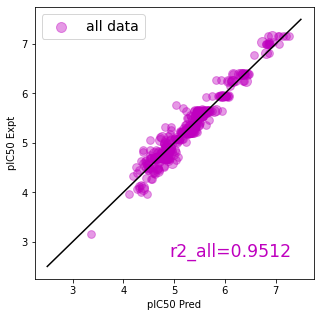

In [13]:
#プロットの定義
def yyplot_pro(model, Y_test, X_test, Y_train, X_train, title):
    
    m1, s1 = mean_train_y, std_train_y
    m2, s2 = mean_test_y, std_test_y
    m3, s3 = mean_all_y, std_all_y
    
    # 説明変数と目的変数のデータ点の散布図をプロット
    fig = plt.figure(figsize=(5,5))
    fig.suptitle(title, fontsize=15)
    
    s=np.linspace(2.5, 7.5, 50)
    t = s
    plt.plot(s, t, color='k')
    
    #Predict
    train_pred = pd.DataFrame(model.predict(X_train), columns=['pIC50'])
    test_pred = pd.DataFrame(model.predict(X_test), columns=['pIC50'])
    #all_pred = pd.DataFrame(model.predict(X_all), columns=['pIC50'])
    
    #plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='blue', marker='.' , label='training set')
    #plt.scatter(m1 + test_pred*s2, m2 + Y_test*s2, color='red', marker='.' , label='test set')
    plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='m', marker='o' , alpha=0.4, s=60)
    plt.scatter(m2 + test_pred*s2, m2 + Y_test*s2, color='m', marker='o' , alpha=0.4, s=100,  label='all data')
    #plt.scatter(m3 + all_pred*s3, m3 + Y_all*s3, color='m', marker='o' , alpha=0.4)
    
    plt.xlabel('pIC50 Pred')  # x軸のラベル
    plt.ylabel('pIC50 Expt')  # y軸のラベル
    #plt.xlim(2.5, 7.5)
    #plt.ylim(2.5, 7.5)
    plt.legend(loc=2, fontsize=14)
    
    # R2値を表示  
    r2_train = r2_score(Y_train, train_pred).round(4)
    r2_test = r2_score(Y_test, test_pred).round(4)
    r2_all = ((r2_train + r2_test)/2).round(4)
    
    #text1 = f'r2_train={r2_train}'
    #text2 = f'r2_test={r2_test}'
    text3 = f'r2_all={r2_all}'
    
    #plt.text(4.9, 3, text1, fontsize="xx-large", color='blue')
    #plt.text(4.9, 2.5, text2, fontsize="xx-large", color='red')
    plt.text(4.9, 2.7, text3, fontsize="xx-large", color='m')

#プロットの作成
yyplot_pro(model_pro, Y_test, dtest, Y_train, dtrain, "")
#plt.savefig("virtual_screening_result/yy_plot_model_pro.png")
plt.savefig("best_model/論文用_yy_plot_model_pro.png")

In [14]:
kampo = pd.read_csv('231207_tateishi_ECFP4_kampo.csv', index_col=0, )
kampo = kampo.dropna(how='any').reset_index()
#kampo = kampo.drop_duplicates(subset='smiles')
all_variables =kampo.columns.values
all_variables
kampo

,number,cid,name,smiles,1,9,10,11,13,14,...,2012,2015,2021,2024,2030,2032,2033,2034,2041,2042
0,kampo_0002,11095734,(+)-Aromadendrene,CC1CCC2C1C3C(C3(C)C)CCC2=C,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,kampo_0003,73533,(+)-Catechin 7-O-beta-D-xyloside,C1C(C(OC2=CC(=CC(=C21)O)OC3C(C(C(CO3)O)O)O)C4=...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,kampo_0004,167812,(+)-Curcumenol,CC1CCC2C13CC(=C(C)C)C(O3)(C=C2C)O,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,kampo_0005,16212927,(+)-Cyclosativene,CC(C)C1CCC2(C3C1C4C2(C4C3)C)C,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,kampo_0006,182232,(+)-Epicatechin,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC(=C(C=C3)O)O)O,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2644,kampo_2996,5282769,trans-11-Eicosenoic acid,CCCCCCCCC=CCCCCCCCCCC(=O)O,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2645,kampo_2997,639662,trans-2-Heptene,CCCCC=CC,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2646,kampo_2998,5284503,trans-3-Hexen-1-ol,CCC=CCCO,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2647,kampo_3001,88302,trans-Pinocarveol,CC1(C2CC1C(=C)C(C2)O)C,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
len(kampo)

2649

In [16]:
#trainig用説明変数
X_kampo = kampo[variables]
X_kampo.head(20)

,1,9,10,11,13,14,16,18,19,25,...,2012,2015,2021,2024,2030,2032,2033,2034,2041,2042
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
dkampo = xgb.DMatrix(X_kampo)
kampo_pred = pd.DataFrame(model_pro.predict(dkampo), columns=['pIC50'])

In [18]:
#プロットの定義
def yyplot_kampo(model, Y_test, X_test, Y_train, X_train, title):
    
    m1, s1 = mean_train_y, std_train_y
    m2, s2 = mean_test_y, std_test_y
    
    # 説明変数と目的変数のデータ点の散布図をプロット
    fig = plt.figure(figsize=(5,5))
    fig.suptitle(title, fontsize=20)
    
    s=np.linspace(2.5, 7.5, 50)
    t = s
    plt.plot(s, t, color='k')
    
    #Predict
    train_pred = pd.DataFrame(model.predict(X_train), columns=['pIC50'])
    test_pred = pd.DataFrame(model.predict(X_test), columns=['pIC50'])
    dkampo = xgb.DMatrix(X_kampo)
    kampo_pred = pd.DataFrame(model.predict(dkampo), columns=['pIC50'])
    #kampo_pred = kampo_pred.sort_values('pIC50', ascending=False)
    kampo_pred =m1 + kampo_pred*s1
    
    plt.scatter(m1 + train_pred*s1, m1 + Y_train*s1, color='blue', marker='.' , label='Training Data')
    plt.scatter(m2 + test_pred*s2, m2 + Y_test*s2, color='red', marker='.' , label='Test Data')
    #plt.scatter(6.44, 6.85, color='green', marker='*',s= 500, label='natural')
    plt.scatter(kampo_pred, len(kampo_pred)*[5], color='green', marker='*',s= 10, label='natural')
    
    plt.xlabel('pIC50 Pred')  # x軸のラベル
    plt.ylabel('pIC50 Expt')  # y軸のラベル
    #plt.xlim(2.5, 7.5)
    #plt.ylim(2.5, 7.5)
    plt.legend(loc=2, fontsize=14)
    
    # R2値を表示  
    r2_train = r2_score(Y_train, train_pred).round(4)
    r2_test = r2_score(Y_test, test_pred).round(4)
    
    text1 = f'r2_train={r2_train}'
    text2 = f'r2_test={r2_test}'
    
    plt.text(4.9, 3, text1, fontsize="xx-large", color='blue')
    plt.text(4.9, 2.5, text2, fontsize="xx-large", color='red')
    
    #plt.rcParams["font.size"] = 15

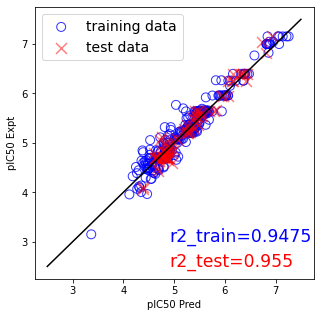

In [19]:
#Predict
train_pred2 = pd.DataFrame(model_pro.predict(dtrain), columns=['pIC50'])
test_pred2 = pd.DataFrame(model_pro.predict(dtest), columns=['pIC50'])

#R2  
m1, s1 = mean_train_y, std_train_y
m2, s2 = mean_test_y, std_test_y
r2_train = r2_score(Y_train, train_pred2).round(4)
r2_test = r2_score(Y_test, test_pred2).round(4)

#プロットの作成
yyplot(model_pro, Y_test, dtest, Y_train, dtrain, "")
#plt.savefig("result_letteryy_plot_T_"+str(i)+".png")
#plt.savefig("result_letter/yy_plot_pro.png")

# SHAP値を計算するためのexplainerを作成
explainer = shap.TreeExplainer(
    model = model_pro,  # 学習済みモデル
    feature_perturbation="interventional"  # 推奨
    )
# SHAP値を計算
shap_values = explainer(X_train, Y_train)

# 棒グラフで重要度を可視化
#fig2 = plt.figure(figsize=(5,5))   #新しいウィンドウを描画
#fig2.subplots()
#shap.plots.bar(shap_values=shap_values, max_display=len(desc_list2), show=False)
#fig2.savefig("result_lettershap_pro.png") # 画像を保存

In [20]:
m, s = mean_train_y, std_train_y
kampo_pred = m + kampo_pred*s
kampo_pred

,pIC50
0,5.295071
1,4.553687
2,5.034102
3,5.195124
4,4.539908
...,...
2644,4.918510
2645,4.856102
2646,4.721993
2647,5.181895


In [21]:
df_sort = kampo_pred.sort_values('pIC50', ascending=False)
len(df_sort)
df_sort

,pIC50
1490,5.936733
1930,5.903327
275,5.883367
1325,5.866986
1324,5.858119
...,...
115,4.012032
1286,4.012032
2387,3.955311
2498,3.904539


In [22]:
result = pd.concat([kampo_pred.reset_index(), kampo.reset_index()], axis=1)
result.to_csv('virtual_screening_result/kampo_virtual_screening_result_1207.csv')

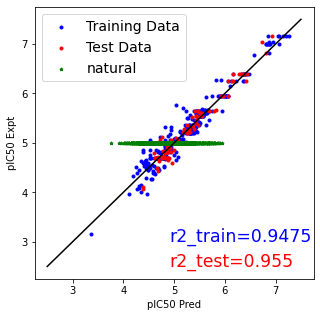

In [23]:
yyplot_kampo(model_pro, Y_test, dtest, Y_train, dtrain, "")